#### Load packages, set home directory

In [1]:
import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_systems as cs
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import glob as sir_globington_the_file_gatherer
import pandas as pd
import numpy as np

homedir='/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/01/'
os.chdir(homedir)

#### Get all files for this ensemble member into one cube

In [2]:
# monthly_cubes_list = iris.load(filenames)
# monthly_cubes_list

In [3]:
# import glob as sir_globington_the_file_gatherer
# yr = 1994
# general_filename = homedir + f'bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr}*01-{yr}*30.nc'

# filenames = []
# for filename in sir_globington_the_file_gatherer.glob(general_filename):
#     filenames.append(filename)
    
# monthly_cubes_list = iris.cube.CubeList(
#     [iris.load(f)[1] for f in filenames])

# cube_1993 = monthly_cubes_list.concatenate_cube()      

In [4]:
yr = 1994

files = []

# December previous year FIRST
files.append(f"{homedir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr-1}1201-{yr-1}1230.nc")

# Jan–Nov of target year
for m in range(1, 12):
    files.append(f"{homedir}bc_pr_rcp85_land-cpm_uk_5km_01_1hr_{yr}{m:02d}01-{yr}{m:02d}30.nc")

monthly_cubes = iris.cube.CubeList()

for f in files:
    cube = iris.load(f)[1]
    cube.attributes = {}
    monthly_cubes.append(cube)

cube_all = monthly_cubes.concatenate_cube()

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable ensemble_member_id referenced by variable pr: Dimensions ('ensemble_member', 'string27') do not span ('time', 'projection_y_coordinate', 'projection_x_coordinate')
  warnings.warn(


In [5]:
# time_coord = cube_all.coord('time')
# print(time_coord)

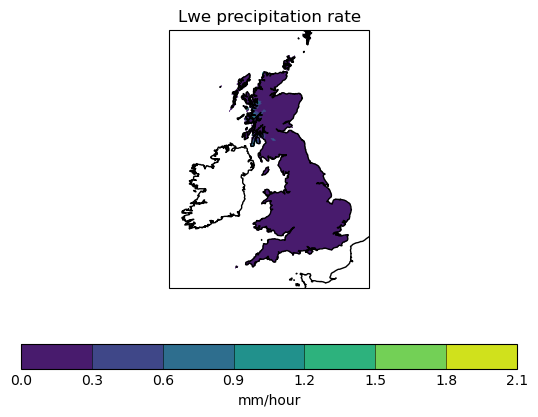

In [6]:
# Get onetimestep
one_timestep = cube_all[0,:,:]

# Plot
qplt.contourf(one_timestep)  # first time slice
plt.gca().coastlines()
plt.show()

## Trim to Newcastle

In [7]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, Polygon

In [8]:
homedir="/scratch/hydro4/users/"
catchments = gpd.read_file(homedir + "kv25483/FutureFlood/Data/NewcastleExample/catchment_identifier/hyd_areas_GB_with_subcatchments.shp")
newcastle = catchments[catchments['HA_NUM'] == "23"]

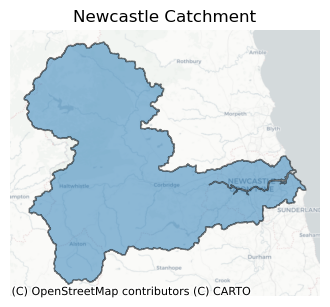

In [9]:
# Convert to Web Mercator
newcastle_web = newcastle.to_crs(epsg=3857)

# Plot polygon
ax = newcastle_web.plot(figsize=(4, 4), alpha=0.5, edgecolor='k')

# Add basemap (robust method)
basemap = ctx.providers.Stamen.TerrainBackground if hasattr(ctx.providers, "Stamen") else ctx.providers.CartoDB.Positron
ctx.add_basemap(ax, source=basemap)

ax.set_title("Newcastle Catchment")
ax.axis('off')
plt.show()

## Trim to Newcastle (hourly original)

In [10]:
from shapely import vectorized
import time
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

### slower version

In [11]:
# Define your catchment polygon in OSGB (list of (x,y) tuples)
catchment_poly = newcastle.geometry[60]

In [12]:
# start_time = time.time()

# # Define your catchment polygon in OSGB (list of (x,y) tuples)
# catchment_poly = newcastle.geometry[60]

# # Extract coordinates
# x = cube_all.coord('projection_x_coordinate').points
# y = cube_all.coord('projection_y_coordinate').points

# # Create 2D meshgrid
# xx, yy = np.meshgrid(x, y)

# # Flatten
# coords_flat = np.vstack([xx.ravel(), yy.ravel()]).T

# # Mask points outside the polygon
# mask = np.array([catchment_poly.contains(Point(px, py)) for px, py in coords_flat])
# mask_2d = mask.reshape(xx.shape)

# # Apply mask to data
# cube_catchment = cube_all.copy()
# cube_catchment.data = np.where(mask_2d, cube_catchment.data, np.nan)

# end_time = time.time()
# print(end_time-start_time)

#### faster version

In [13]:
start_time = time.time()

# --- Extract cube coordinates ---
x = cube_all.coord('projection_x_coordinate').points
y = cube_all.coord('projection_y_coordinate').points

# --- Create grid matching cube order (X,Y) ---
xx, yy = np.meshgrid(x, y)

# --- Vectorised point-in-polygon mask (fast) ---
mask_2d = vectorized.contains(catchment_poly, xx, yy)

# If you prefer to include boundary-touching cells instead:
# mask_2d = vectorized.intersects(catchment_poly, xx, yy)

# --- Apply mask across all timesteps ---
cube_catchment = cube_all.copy()
cube_catchment.data = np.where(
    mask_2d[np.newaxis, :, :],   # expand mask to (time,X,Y)
    cube_catchment.data,
    np.nan)

end_time = time.time()
print(end_time-start_time)

/tmp/ipykernel_168224/1090784664.py:11: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask_2d = vectorized.contains(catchment_poly, xx, yy)


23.13943123817444


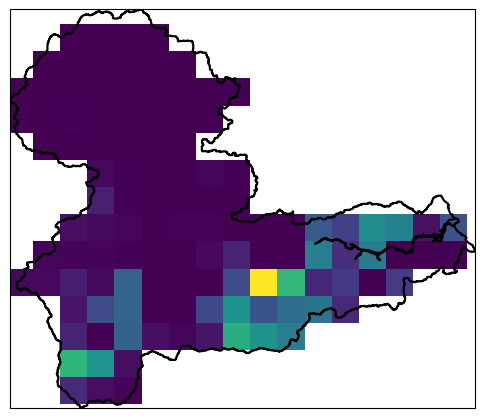

In [14]:
fig, ax = plt.subplots(
    figsize=(6,6),
    subplot_kw={'projection': ccrs.OSGB()})

iplt.pcolormesh(cube_catchment[0], axes=ax)

minx, miny, maxx, maxy = catchment_poly.bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.OSGB())

newcastle.boundary.plot(ax=ax, color='black')

plt.show()

#### Rainfall event csvs

In [15]:
import pandas as pd
home_dir = "/scratch/hydro4/users/" # kv25483/"
ncl_events = pd.read_csv(home_dir + "la17355/FUTURE-FLOOD/UKCP_rainfall_events/fixed_threshold_30mm_with_volume/Tyne(Northumberland)_01_full_events_with_event_nums.csv")
ncl_events[ncl_events['start_year']==1994]
# plt.hist(ncl_events['start_month'])

,start_indices,stop_indices,event_durations,peaks,start_year,start_month,start_day,start_hour,start_time,stop_time,start_time_seconds,stop_time_seconds,event_vol,max_extent,acc_total,acc_3hr,acc_6hr,acc_12hr,acc_24hr,event_num
1,5293,5303,10,32.84921,1994,7,11,12,211932.5,211942.5,762957000,762993000,126.233498,5,126.233498,115.582377,126.232947,NaN,NaN,2
2,5384,5411,27,56.25648,1994,7,15,7,212023.5,212050.5,763284600,763381800,1854.094660,75,1854.094660,586.499210,857.442260,1223.954138,1847.511375,3


In [16]:
# one_month_cube = cube_catchment.extract(iris.Constraint(time=lambda cell: cell.point.month == 8))

#### This finds the maximum precipitation and where it occurred

In [28]:
event_idx=1
start_index = int(ncl_events.iloc[event_idx]['start_indices'])-1
stop_index = int(ncl_events.iloc[event_idx]['stop_indices'])-1

In [30]:
subset = cube_catchment[start_index:stop_index, :, :].data

# find index of maximum value
flat_index = np.nanargmax(subset)

# convert to (time, x, y) indices
t_local, y_idx, x_idx = np.unravel_index(flat_index, subset.shape)

# actual precipitation value
max_precip = subset[t_local, y_idx, x_idx]

# convert time index back to original cube index
t_global = t_local + start_index

print("Max precipitation:", max_precip)
print("Time index:", t_global)
print("Grid cell indices (x,y):", x_idx, y_idx)

Max precipitation: 32.849205
Time index: 5295
Grid cell indices (x,y): 115 118


#### Get just the timestep with the maximum

In [31]:
# extract timestep cube
peak_slice = cube_all[t_global, :, :]

# coordinates of peak cell
x_coord = cube_all.coord('projection_x_coordinate').points[x_idx]
y_coord = cube_all.coord('projection_y_coordinate').points[y_idx]

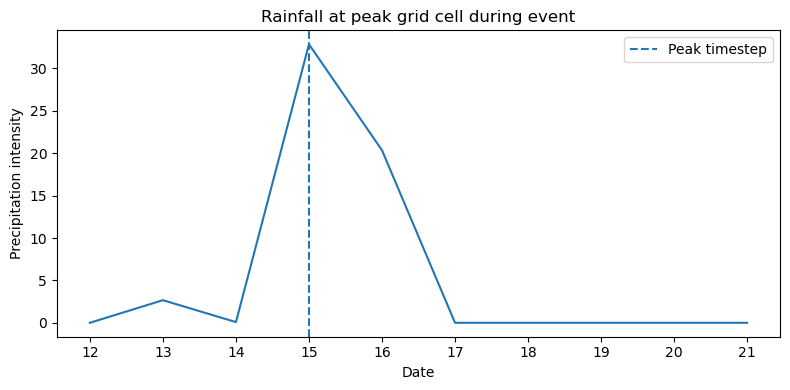

In [32]:
# Extract event time series
ts = cube_catchment[start_index:stop_index, y_idx, x_idx]

times = ts.coord('yyyymmddhh').points.astype(int)
values = ts.data

# Convert to datetime
dt = pd.to_datetime(times.astype(str), format="%Y%m%d%H")

# Plot
plt.figure(figsize=(8,4))
plt.plot(dt, values)

# Mark peak timestep
peak_time = cube_catchment.coord('yyyymmddhh').points[t_global]
peak_dt = pd.to_datetime(str(int(peak_time)), format="%Y%m%d%H")
plt.axvline(peak_dt, linestyle='--', label='Peak timestep')

# Format ticks
plt.gca().xaxis.set_major_formatter(
#     plt.matplotlib.dates.DateFormatter('%d %b %H')
    plt.matplotlib.dates.DateFormatter('%H')
)

plt.xlabel("Date")
plt.ylabel("Precipitation intensity")
plt.title("Rainfall at peak grid cell during event")
plt.legend()

plt.tight_layout()
plt.show()

#### Plot

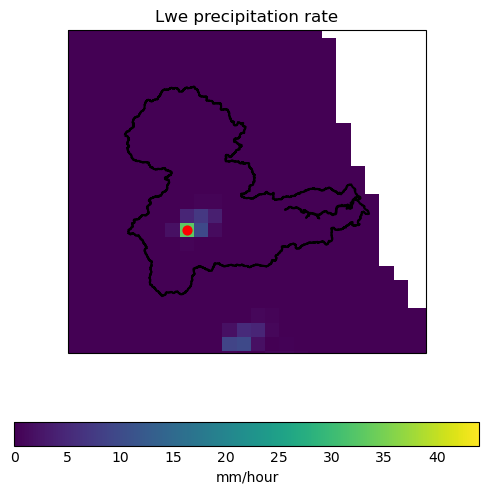

In [33]:
fig, ax = plt.subplots(
    figsize=(6,6),
    subplot_kw={'projection': ccrs.OSGB()})

qplt.pcolormesh(peak_slice, axes=ax)

buffer = 20000  # 15 km in metres
minx, miny, maxx, maxy = catchment_poly.bounds
ax.set_extent([minx - buffer, maxx + buffer, miny - buffer, maxy + buffer],crs=ccrs.OSGB())

ax.scatter(x_coord, y_coord, color='red', s=40, transform=ccrs.OSGB(), label='Peak cell')

newcastle.boundary.plot(ax=ax, color='black')

plt.show()

In [22]:
# # Extract the rainfall field at the peak timestep
# peak_field = cube_catchment[t_global, :, :].data

# # Peak value
# peak_value = peak_field[y_idx, x_idx]

# # Threshold
# threshold = 0.3 * peak_value

# # Define neighborhood slice (you can use full array if you want)
# ny, nx = peak_field.shape

# # Optional: define max search distance, e.g., 10 cells
# radius = 10
# ymin = max(0, y_idx - radius)
# ymax = min(ny, y_idx + radius + 1)
# xmin = max(0, x_idx - radius)
# xmax = min(nx, x_idx + radius + 1)

# neighborhood = peak_field[ymin:ymax, xmin:xmax]

# # Count cells above threshold (excluding the central peak cell if desired)
# mask = neighborhood >= threshold
# num_cells = np.sum(mask) - 1  # subtract 1 to exclude the central peak itself

# print(f"Number of surrounding cells > 80% of peak: {num_cells}")

In [47]:
from scipy.ndimage import label

# # Extract the rainfall field at the peak timestep
peak_field = cube_catchment[t_global, :, :].data

# Peak value
peak_value = peak_field[y_idx, x_idx]
# threshold
threshold = 0.2* peak_value

# Extract the rainfall field at the peak timestep
peak_field = cube_catchment[t_global, :, :].data

mask = peak_field >= threshold
labeled, num_features = label(mask)

# The label of the peak cell
peak_label = labeled[y_idx, x_idx]

# Number of cells in the same connected cluster as the peak
cluster_size = np.sum(labeled == peak_label) - 1  # exclude central peak
print("Number of connected cells >80% of peak:", cluster_size)


Number of connected cells >80% of peak: 2


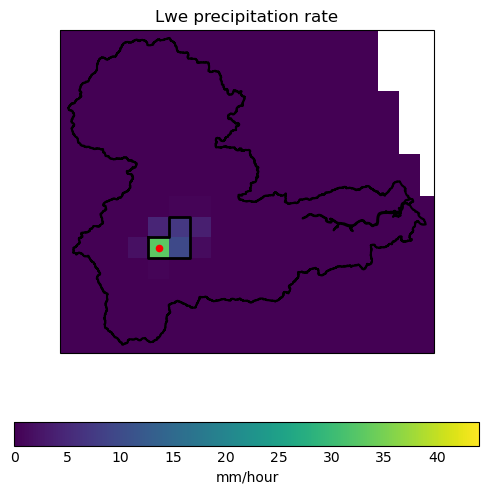

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import iris.quickplot as qplt
import cartopy.crs as ccrs
from shapely.geometry import box, MultiPolygon
from shapely.ops import unary_union

fig, ax = plt.subplots(figsize=(6,6),subplot_kw={'projection': ccrs.OSGB()})

# --- Base rainfall field ---
qplt.pcolormesh(peak_slice, axes=ax)

rain = peak_slice.data
peak_value = rain[y_idx, x_idx]
threshold = 0.2 * peak_value

mask = rain >= threshold
ys, xs = np.where(mask)

# grid coordinates
x = peak_slice.coord('projection_x_coordinate').points
y = peak_slice.coord('projection_y_coordinate').points

dx = x[1] - x[0]
dy = y[1] - y[0]

# create a square polygon for each grid cell
cells = [box(x[xi]-dx/2, y[yi]-dy/2, x[xi]+dx/2, y[yi]+dy/2)
         for yi, xi in zip(ys, xs)]

# merge cells
storm_core = unary_union(cells)

# handle MultiPolygon
if isinstance(storm_core, MultiPolygon):
    polygons = storm_core.geoms
else:
    polygons = [storm_core]

# plot each polygon boundary
for poly in polygons:
    xs_poly, ys_poly = poly.exterior.xy
    ax.plot(xs_poly, ys_poly, color='black', linewidth=2, transform=ccrs.OSGB())

##############
# --- Plot peak grid cell ---
x = peak_slice.coord('projection_x_coordinate').points
y = peak_slice.coord('projection_y_coordinate').points

ax.scatter(
    x[x_idx],
    y[y_idx],
    color='red',
    s=20,
    transform=ccrs.OSGB(),
    label='Peak cell')

# --- Catchment extent with buffer ---
buffer = 2000  # metres
minx, miny, maxx, maxy = catchment_poly.bounds
ax.set_extent([minx-buffer, maxx+buffer, miny-buffer, maxy+buffer],crs=ccrs.OSGB())

# --- Catchment boundary ---
newcastle.boundary.plot(ax=ax, color='black')

# ax.legend()

plt.show()

In [50]:

rain = peak_slice.data

print("Peak:", peak_value)
print("Threshold:", threshold)
print("Cells above threshold:", np.sum(rain >= threshold))

Peak: 32.849205
Threshold: 6.569841003417969
Cells above threshold: 167
